In [38]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import tarfile
import zipfile
import shutil
import datetime
from tqdm.auto import tqdm

# Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Kaggle Directory Structure
WORKING_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
INPUT_DIR = "/kaggle/input" if os.path.exists("/kaggle/input") else "."

# --- Constants ---
BOLD_NAMES = [
    "rfMRI_REST1_LR", "rfMRI_REST1_RL", "rfMRI_REST2_LR", "rfMRI_REST2_RL",
    "tfMRI_MOTOR_RL", "tfMRI_MOTOR_LR", "tfMRI_WM_RL", "tfMRI_WM_LR",
    "tfMRI_EMOTION_RL", "tfMRI_EMOTION_LR", "tfMRI_GAMBLING_RL", "tfMRI_GAMBLING_LR",
    "tfMRI_LANGUAGE_RL", "tfMRI_LANGUAGE_LR", "tfMRI_RELATIONAL_RL", "tfMRI_RELATIONAL_LR",
    "tfMRI_SOCIAL_RL", "tfMRI_SOCIAL_LR"
]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- Data Environment Setup ---
def setup_environment():
    """Consolidated path discovery and data acquisition logic."""
    global RAW_REST_DIR, RAW_TASK_DIR, FC_DATA_DIR
    
    # 1. Check for Zip & Extract if needed
    has_subjects = False
    for root, dirs, _ in os.walk(WORKING_DIR):
        if "subjects" in dirs:
            has_subjects = True
            break
    
    if not has_subjects:
        for root, _, files in os.walk(INPUT_DIR):
            if "DATA.zip" in files:
                zip_path = os.path.join(root, "DATA.zip")
                print(f">>> Extracting {zip_path}...")
                with zipfile.ZipFile(zip_path, 'r') as z:
                    z.extractall(WORKING_DIR)
                break
    
    # 2. Locate Raw Data (Searching for 'subjects' folders)
    RAW_REST_DIR = None
    RAW_TASK_DIR = None
    
    for d in [INPUT_DIR, WORKING_DIR]:
        for root, dirs, _ in os.walk(d):
            if "subjects" in dirs:
                # Prioritize paths with 'rest' or 'task' keywords
                if "rest" in root.lower():
                    RAW_REST_DIR = root
                elif "task" in root.lower() or "motor" in root.lower() or "hcp_task" in root.lower():
                    RAW_TASK_DIR = root
                
                # Broad fallback
                if RAW_REST_DIR is None: RAW_REST_DIR = root
                if RAW_TASK_DIR is None: RAW_TASK_DIR = root
    
    # 3. Locate Pre-calculated FC Data
    fc_dir = os.path.join(WORKING_DIR, "FC_DATA")
    for root, _, files in os.walk(INPUT_DIR):
        if "fc_rest.npy" in files:
            fc_dir = root
            break
    FC_DATA_DIR = fc_dir
    
    # 4. Initialize working directories
    os.makedirs(os.path.join(WORKING_DIR, "FC_DATA"), exist_ok=True)

    print(f"--- Environment Verified ---")
    print(f"Device: {DEVICE.upper()}")
    print(f"Raw Rest: {RAW_REST_DIR or 'Not Found'}")
    print(f"Raw Task: {RAW_TASK_DIR or 'Not Found'}")
    print(f"FC Data Path: {fc_dir}")
    print(f"----------------------------\n")

setup_environment()
SAVE_DIR = os.path.join(WORKING_DIR, "FC_DATA")
TRIL_IDX = np.tril_indices(360, k=-1) # Cached Glasser-360 indices


--- Environment Verified ---
Device: CUDA
Raw Rest: /kaggle/input/hcp-dataset-s1200/hcp_rest
Raw Task: /kaggle/input/hcp-dataset-s1200/hcp_task
FC Data Path: /kaggle/working/FC_DATA
----------------------------



In [39]:
# %% [markdown]
# ## 2. Core Architecture
# Implementation of the ConvAutoencoder for Task-Common Noise removal.

# %%
class ConvAutoencoder(nn.Module):
    def __init__(self, n_parcels=360):
        super(ConvAutoencoder, self).__init__()
        self.n = n_parcels
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        # Ensure output size matches input exactly (handling odd parcel counts)
        if decoded.shape[2:] != (self.n, self.n):
            decoded = F.interpolate(decoded, size=(self.n, self.n), mode='bilinear', align_corners=True)
        return decoded

In [40]:
# %% [markdown]
# ## 3. Scientific Refinement Logic (SDL)
# We implement K-SVD to extract the sparse, individual-specific components of the functional connectome.

# %%
def omp(y, D, n_nonzero_coefs):
    n = D.shape[1]
    x = np.zeros(n)
    residual = y.copy()
    indices = []
    for _ in range(n_nonzero_coefs):
        proj = D.T @ residual
        idx = np.argmax(np.abs(proj))
        if idx in indices: break
        indices.append(idx)
        D_selected = D[:, indices]
        x_selected, _, _, _ = np.linalg.lstsq(D_selected, y, rcond=None)
        residual = y - D_selected @ x_selected
    x[indices] = x_selected
    return x

def k_svd(Y, K, L, max_iter=5):
    m, n = Y.shape
    D = np.random.randn(m, K)
    D /= np.linalg.norm(D, axis=0)
    X = np.zeros((K, n))
    for it in range(max_iter):
        for i in range(n):
            X[:, i] = omp(Y[:, i], D, L)
        for j in range(K):
            idx = np.where(X[j, :] != 0)[0]
            if len(idx) == 0: continue
            D[:, j] = 0
            R = Y[:, idx] - D @ X[:, idx]
            u, s, vt = np.linalg.svd(R, full_matrices=False)
            D[:, j] = u[:, 0]
            X[j, idx] = s[0] * vt[0, :]
    return D, X

def reconstruct_symmetric_matrix(tri_elements, n=360):
    matrix = np.zeros((n, n))
    matrix[TRIL_IDX] = tri_elements
    matrix += matrix.T
    np.fill_diagonal(matrix, 1.0)
    return matrix

def get_acc(t_f, r_f, n_subjects):
    with np.errstate(divide='ignore', invalid='ignore'):
        c = np.corrcoef(t_f, r_f)[:n_subjects, n_subjects:]
        c = np.nan_to_num(c, nan=0.0)
    return np.mean(np.argmax(c, axis=1) == np.arange(n_subjects)) * 100


def perform_grid_search(Y, rest_flat, n_subjects, n_parcels):
    print("\n--- Running SDL Grid Search (K: 2-15, L: 2-K) ---")
    results = np.zeros((16, 16)) # Max K+1, Max L+1
    
    for k in tqdm(range(2, 16), desc="Grid Search K"):
        # L must be <= K
        for l in range(2, k + 1):
            D, X = k_svd(Y, K=k, L=l, max_iter=3) # Fewer iterations for speed
            DX_flat = (D @ X).T
            
            # Use small batch reconstruction for accuracy check
            refined_flat = np.zeros((n_subjects, len(TRIL_IDX[0])))
            for i in range(n_subjects):
                # We need the task_residual flat for this
                # But to save memory/time, we can work directly on Y (which is task_residual_flat)
                refined_flat[i] = Y[:, i] - DX_flat[i]
            
            results[k, l] = get_acc(refined_flat, rest_flat, n_subjects)
            
    return results

def save_and_zip_results(output_dir):
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    zip_name = f"results_{timestamp}"
    shutil.make_archive(os.path.join(WORKING_DIR, zip_name), 'zip', output_dir)
    print(f"\n>>> Results bundled into: {zip_name}.zip")

In [41]:
# --- Functional Connectivity Generation ---
def get_image_ids(name):
    run_ids = [i for i, code in enumerate(BOLD_NAMES, 1) if name.upper() in code]
    if not run_ids: raise ValueError(f"Found no data for '{name}'")
    return run_ids

def load_single_timeseries(subject_id, bold_run, base_dir, remove_mean=True):
    bold_path = os.path.join(base_dir, "subjects", str(subject_id), "timeseries")
    bold_file = f"bold{bold_run}_Atlas_MSMAll_Glasser360Cortical.npy"
    full_path = os.path.join(bold_path, bold_file)
    if not os.path.exists(full_path):
        return None
    ts = np.load(full_path)
    if remove_mean:
        ts -= ts.mean(axis=1, keepdims=True)
    return ts

def generate_fc_for_task(task_name, subjects_list, base_dir, n_parcels=360):
    print(f">>> Generating {task_name} FC...")
    run_ids = get_image_ids(task_name)
    n_runs = 4 if task_name == "rest" else 2
    
    fc_all, subs_idx = [], []
    for idx, sub_id in enumerate(tqdm(subjects_list, desc=task_name.upper())):
        all_runs = [load_single_timeseries(sub_id, run_ids[0] + r, base_dir) for r in range(n_runs)]
        ts_list = [ts for ts in all_runs if ts is not None]
        if ts_list:
            fc_all.append(np.corrcoef(np.concatenate(ts_list, axis=1)))
            subs_idx.append(sub_id) # Store actual subject ID, not index
            
    return np.array(fc_all), subs_idx

In [42]:
# %% [markdown]
# ## 4. Full Pipeline Engine
# This function orchestrates the entire process from data to accuracy report.

# %%
def run_end_to_end(n_subjects=339, n_parcels=360, use_synthetic=True, task="motor"):
    # --- PHASE 1: DATA ACQUISITION ---
    if use_synthetic:
        print(">>> Mode: Synthetic Demo")
        rest_data = np.random.randn(n_subjects, n_parcels, n_parcels)
        task_data = rest_data + 0.6 * np.random.randn(n_subjects, n_parcels, n_parcels)
    else:
        print(f">>> Mode: Real HCP Data (Task: {task})")
        
        # Define save paths in /kaggle/working/FC_DATA
        save_rest_path = os.path.join(SAVE_DIR, "fc_rest.npy")
        save_task_path = os.path.join(SAVE_DIR, f"fc_{task}.npy")
        
        # Check if they exist (either in input or working/output)
        input_rest_path = os.path.join(FC_DATA_DIR, "fc_rest.npy")
        input_task_path = os.path.join(FC_DATA_DIR, f"fc_{task}.npy")
        
        if os.path.exists(input_rest_path) and os.path.exists(input_task_path):
            print(f">>> Loading pre-calculated matrices from {FC_DATA_DIR}")
            rest_data = np.load(input_rest_path)
            task_data = np.load(input_task_path)
            
            # Slice to requested subject count if necessary
            if rest_data.shape[0] > n_subjects:
                print(f">>> Slicing dataset from {rest_data.shape[0]} to {n_subjects} subjects.")
                rest_data = rest_data[:n_subjects]
                task_data = task_data[:n_subjects]
        else:
            print(">>> Matrices not found. Attempting to generate from raw timeseries...")
            if RAW_REST_DIR is None or RAW_TASK_DIR is None:
                raise FileNotFoundError(f"Required raw data folders ('subjects/') not found.\nRest Folder: {RAW_REST_DIR}\nTask Folder: {RAW_TASK_DIR}")
            
            # Rest Generation
            subjects_rest_path = os.path.join(RAW_REST_DIR, "subjects")
            subjects_list = sorted([d for d in os.listdir(subjects_rest_path) if os.path.isdir(os.path.join(subjects_rest_path, d))])
            
            if n_subjects < len(subjects_list):
                subjects_list = subjects_list[:n_subjects]
            
            rest_data, rest_subs = generate_fc_for_task("rest", subjects_list, RAW_REST_DIR, n_parcels)
            task_data, task_subs = generate_fc_for_task(task, subjects_list, RAW_TASK_DIR, n_parcels)
            
            if len(rest_data) == 0 or len(task_data) == 0:
                raise ValueError(f"No valid timeseries files found in the specified directories.\nCheck: {RAW_REST_DIR} and {RAW_TASK_DIR}")

            # Intersection of subjects who have both rest and task data
            valid_subs = sorted(list(set(rest_subs) & set(task_subs)))
            rest_data = rest_data[[rest_subs.index(s) for s in valid_subs]]
            task_data = task_data[[task_subs.index(s) for s in valid_subs]]
            
            print(f">>> Generated FC for {len(valid_subs)} subjects.")
            
            # Save for subsequent runs
            np.save(save_rest_path, rest_data)
            np.save(save_task_path, task_data)
            print(f">>> Saved generated matrices to {SAVE_DIR}")

        # Final Verification
        if rest_data.shape[0] != task_data.shape[0]:
            raise ValueError(f"Subject count mismatch: Rest({rest_data.shape[0]}) vs Task({task_data.shape[0]})")
        if rest_data.shape[1] != n_parcels:
            print(f">>> Warning: Parcel count in data ({rest_data.shape[1]}) differs from config ({n_parcels}). Updating config.")
            n_parcels = rest_data.shape[1]

        n_subjects = rest_data.shape[0]

    # --- PHASE 2: CONV-AE DENOISING ---
    print("\n--- Phase 2: Denoising common task noise ---")
    rest_tensor = torch.tensor(rest_data[:, np.newaxis, :, :], dtype=torch.float32)
    task_tensor = torch.tensor(task_data[:, np.newaxis, :, :], dtype=torch.float32)
    
    model = ConvAutoencoder(n_parcels).to(DEVICE)
    dataset = TensorDataset(rest_tensor, rest_tensor)
    loader = DataLoader(dataset, batch_size=16, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    for ep in tqdm(range(20), desc="Training Autoencoder"):
        for b_in, _ in loader:
            b_in = b_in.to(DEVICE)
            optimizer.zero_grad()
            out = model(b_in)
            loss = nn.MSELoss()(out, b_in)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        task_reconstr = model(task_tensor.to(DEVICE)).cpu().numpy().squeeze()
    
    task_residual = task_data - task_reconstr

 # --- PHASE 3: SDL REFINEMENT & GRID SEARCH ---
    print("\n--- Phase 3: Extracting individual fingerprints (SDL) ---")
    n_tri = int(n_parcels * (n_parcels - 1) / 2)
    Y = np.zeros((n_tri, n_subjects))
    for i in range(n_subjects):
        Y[:, i] = task_residual[i][TRIL_IDX]
    
    # 1. Prepare data for accuracy checks
    def flatten_tril(batch): return np.array([mat[TRIL_IDX] for mat in batch])
    rest_flat = flatten_tril(rest_data)
    task_flat = flatten_tril(task_data)
    resid_flat = flatten_tril(task_residual)

    # 2. Grid Search for K and L
    grid_results = perform_grid_search(Y, rest_flat, n_subjects, n_parcels)
    
    # 3. Use best parameters for final refinement
    best_idx = np.unravel_index(np.argmax(grid_results), grid_results.shape)
    best_k, best_l = best_idx
    print(f">>> Best Parameters found: K={best_k}, L={best_l} (Acc: {grid_results[best_k, best_l]:.2f}%)")
    
    D_final, X_final = k_svd(Y, K=best_k, L=best_l, max_iter=5)
    DX_flat = (D_final @ X_final).T
    
    final_refined = np.zeros((n_subjects, n_parcels, n_parcels))
    for i in range(n_subjects):
        final_refined[i] = task_residual[i] - reconstruct_symmetric_matrix(DX_flat[i], n_parcels)

    refined_flat = flatten_tril(final_refined)

    # --- PHASE 4: EVALUATION & VISUALIZATION ---
    print("\n--- Phase 4: Identification Analysis ---")
    
    acc_raw = get_acc(task_flat, rest_flat, n_subjects)
    acc_res = get_acc(resid_flat, rest_flat, n_subjects)
    acc_ref = get_acc(refined_flat, rest_flat, n_subjects)

    print(f"Accuracy (Baseline): {acc_raw:.2f}% | (ConvAE): {acc_res:.2f}% | (ConvAE+SDL): {acc_ref:.2f}%")

    # Create run directory
    run_dir = os.path.join(WORKING_DIR, f"run_{datetime.datetime.now().strftime('%H%M%S')}")
    os.makedirs(run_dir, exist_ok=True)

    # 1. Subject Correlation Matrices Plots
    fig, axes = plt.subplots(1, 4, figsize=(32, 7))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    
    c_raw = np.corrcoef(task_flat, rest_flat)[:n_subjects, n_subjects:]
    c_res = np.corrcoef(resid_flat, rest_flat)[:n_subjects, n_subjects:]
    c_ref = np.corrcoef(refined_flat, rest_flat)[:n_subjects, n_subjects:]
    
    sns.heatmap(c_raw, ax=axes[0], cmap=cmap, cbar=True)
    axes[0].set_title(f"Case 1: Baseline (Acc: {acc_raw:.1f}%)")
    
    sns.heatmap(c_res, ax=axes[1], cmap=cmap, cbar=True)
    axes[1].set_title(f"Case 2: ConvAE Residuals (Acc: {acc_res:.1f}%)")
    
    sns.heatmap(c_ref, ax=axes[2], cmap=cmap, cbar=True)
    axes[2].set_title(f"Case 3: Refined (SDL) (Acc: {acc_ref:.1f}%)")
    
    sns.heatmap(c_ref - c_raw, ax=axes[3], cmap="RdBu_r", center=0)
    axes[3].set_title("Improvement (Refined - Baseline)")
    
    plt.savefig(os.path.join(run_dir, "correlation_matrices.png"), bbox_inches='tight', dpi=150)
    plt.show()

    # 2. Grid Search Heatmap
    plt.figure(figsize=(10, 8))
    # Slice to 2-15 range
    heat_data = grid_results[2:16, 2:16]
    sns.heatmap(heat_data, annot=True, fmt=".1f", cmap="YlGnBu", 
                xticklabels=range(2, 16), yticklabels=range(2, 16))
    plt.title(f"SDL Accuracy Heatmap (Task: {task})")
    plt.xlabel("L (Sparsity)")
    plt.ylabel("K (Dictionary Size)")
    plt.savefig(os.path.join(run_dir, "grid_search_heatmap.png"), bbox_inches='tight', dpi=150)
    plt.show()

    # 3. Save Numerical Results
    with open(os.path.join(run_dir, "metrics.txt"), "w") as f:
        f.write(f"Task: {task}\n")
        f.write(f"Subjects: {n_subjects}\n")
        f.write(f"Best K: {best_k}, Best L: {best_l}\n")
        f.write(f"Accuracy Baseline: {acc_raw:.2f}%\n")
        f.write(f"Accuracy ConvAE: {acc_res:.2f}%\n")
        f.write(f"Accuracy Refined: {acc_ref:.2f}%\n")

    # Final Zipping
    save_and_zip_results(run_dir)

>>> Mode: Real HCP Data (Task: emotion)
>>> Loading pre-calculated matrices from /kaggle/working/FC_DATA

--- Phase 2: Denoising common task noise ---


Training Autoencoder:   0%|          | 0/20 [00:00<?, ?it/s]


--- Phase 3: Extracting individual fingerprints (SDL) ---

--- Running SDL Grid Search (K: 2-15, L: 2-K) ---


Grid Search K:   0%|          | 0/14 [00:00<?, ?it/s]

>>> Best Parameters found: K=8, L=5 (Acc: 93.33%)

--- Phase 4: Identification Analysis ---
Accuracy (Baseline): 56.67% | (ConvAE): 56.67% | (ConvAE+SDL): 76.67%


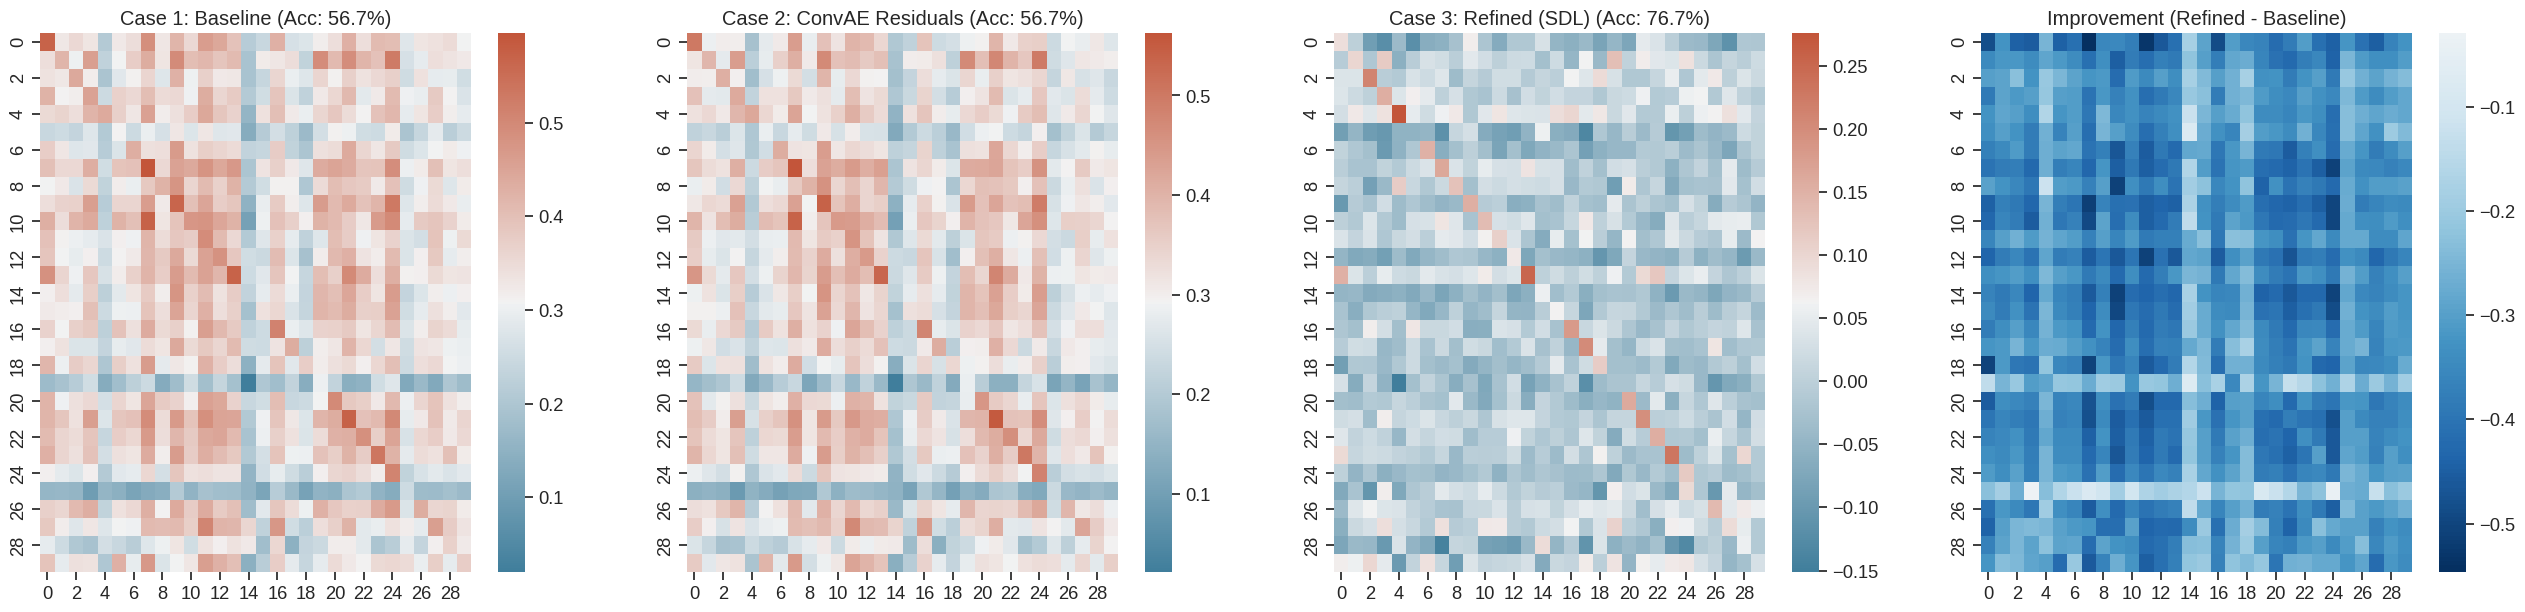

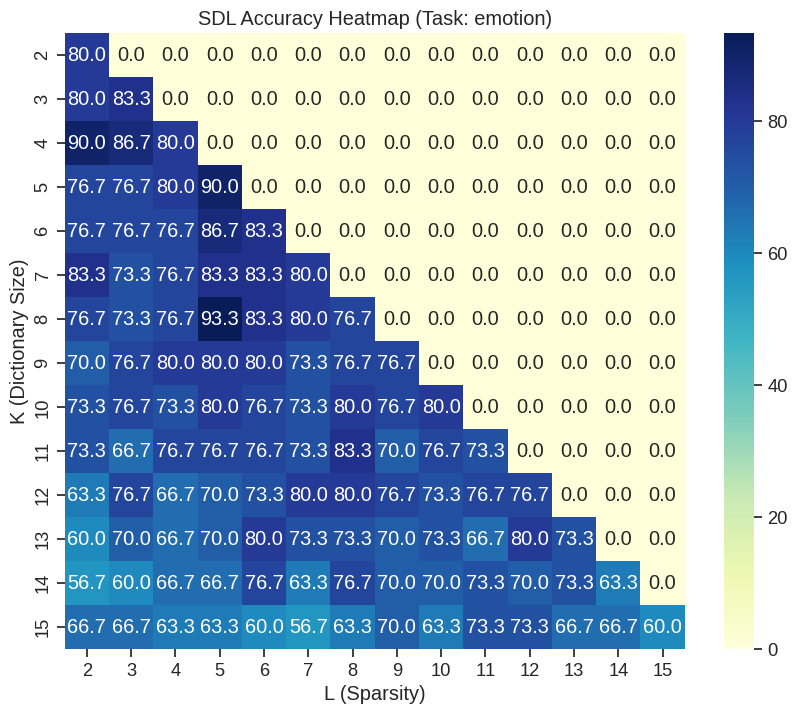


>>> Results bundled into: results_20260120_104555.zip


In [43]:
# %% [markdown]
# ## 5. Execution
# Run the pipeline. Change `use_synthetic=False` if you have preprocessed real data.

# %%
if __name__ == "__main__":
    # Settings
    USE_SYNTHETIC = False  # Set to False to run on real HCP data if uploaded to Kaggle
    TASK_NAME = "emotion"   # options: motor, wm, emotion, gambling, language, relational, social
    
    run_end_to_end(n_subjects=30, use_synthetic=USE_SYNTHETIC, task=TASK_NAME)
